# DDPG: Deep Deterministic Policy Gradient

## Install Dependencies

In [1]:
!pip install swig
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 34.3 MB/s eta 0:00:00
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp310-cp310-linux_x86_64.whl size=2376477 sha256=e293dc2001f32381b0f0458844ab4f252eeca2a8224e306efab75a6db3b8e0e4
  Stored in directory: /root/.cache/pip/wheels/db/8f/6a/eaaadf056fba10a98d986f6dce954e6201ba3126926fc5ad9e
Successfully built box2d-py


## Helpers

In [2]:
# Video management imports
import cv2
import matplotlib.pyplot as plt

# Check if we running in Google Colab or Jupyter Notebook
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Running in Google Colab')
    # Do you need to connect with Google Drive? Uncomment the next two lines
    # from google.colab import drive
    # drive.mount('/content/drive')
    # This auxiliary function simplifies the visualization of OpenCV Images
    from google.colab.patches import cv2_imshow
else:
    print('Running in Jupyter Notebook')
    # This auxiliary function simplifies the visualization of OpenCV Images
    def cv2_imshow(img, title=''):
        if img.ndim > 2:
            img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # view the image in its natural size
            plt.figure(figsize=(img.shape[1], img.shape[0]), dpi=1)
            plt.imshow(img)
            plt.title(title)
            plt.xticks([]), plt.yticks([])
            plt.show()
        else:
            # view the image in its natural size
            plt.figure(figsize=(img.shape[1], img.shape[0]), dpi=1)
            plt.imshow(img, cmap='gray')
            plt.title(title)
            plt.xticks([]), plt.yticks([])
            plt.show()

# Helper functions to save videos and images
def save_video(img_array, path='/content/test.mp4'):
  height, width, layers = img_array[0].shape
  size = (width, height)
  out = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*'MP4V'), 15, size)
  if out.isOpened():
    for i in range(len(img_array)):
      bgr_img = cv2.cvtColor(img_array[i], cv2.COLOR_RGB2BGR)
      out.write(bgr_img)
    out.release()
    print('Video saved.')
  else:
    print(f'Could not save video path: {path}')

Running in Google Colab


# DDPG: Deep Deterministic Policy Gradient

DDPG is designed specifically for continuous action spaces. It is an actor-critic method that uses deterministic policies to handle environments where actions are continuous.

Compared to A2C or REINFORCE it uses a **deterministic policy** to select actions.

As the policy is deterministic, the algorithm needs external systems to enable exploring the environment. It usually relies on **adding noise** (e.g., Ornstein-Uhlenbeck process or Gaussian noise) to the deterministic policy's actions for exploration during training

DDPG is an **off-policy algorithm that uses experience replay** to store and learn from past experiences, allowing for better sample efficiency.

## Imports

In [3]:
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

## Actor Critic networks

The networks are straightforward. Notice the tanh activation of the actor to cap the values in the range [-1, 1]. This values will be later expanded to the actual range of our actions.

In [4]:
class Actor(nn.Module):
    def __init__(self, state_size, action_size, max_action):
        super(Actor, self).__init__()
        self.max_action = max_action

        self.l1 = nn.Linear(state_size, 400)
        self.l2 = nn.Linear(400, 300)
        self.l3 = nn.Linear(300, action_size)

    def forward(self, state):
        a = torch.relu(self.l1(state))
        a = torch.relu(self.l2(a))
        a = torch.tanh(self.l3(a))  # Output in range [-1, 1]
        return a * self.max_action


In [5]:
class Critic(nn.Module):
    def __init__(self, state_size, action_size):
        super(Critic, self).__init__()

        # Q1 architecture
        self.l1 = nn.Linear(state_size + action_size, 400)
        self.l2 = nn.Linear(400, 300)
        self.l3 = nn.Linear(300, 1)

    def forward(self, state, action):
        q = torch.relu(self.l1(torch.cat([state, action], 1)))
        q = torch.relu(self.l2(q))
        q = self.l3(q)
        return q


## Replay Buffer

In [6]:
class ReplayBuffer(object):
    def __init__(self, max_size=int(1e6)):
        self.buffer = deque(maxlen=max_size)

    def add(self, state, action, next_state, reward, done):
        self.buffer.append((state, action, next_state, reward, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, next_state, reward, done = map(np.stack, zip(*batch))
        return (
            torch.FloatTensor(state),
            torch.FloatTensor(action),
            torch.FloatTensor(next_state),
            torch.FloatTensor(reward).unsqueeze(1),
            torch.FloatTensor(done).unsqueeze(1)
        )

    def size(self):
        return len(self.buffer)


## Agent Definition

### Critic Loss

The critic network in DDPG estimates the Q-value function, which predicts the expected return of taking a given action in a given state. The critic loss is based on the mean squared error (MSE) between the predicted Q-values and the target Q-values. The target Q-value is computed using the target networks, which are slowly updated versions of the actor and critic networks. The critic loss is given by:

$
\mathcal{L}(Q_{\theta}) = \mathbb{E}_{(s_t, a_t, r_t, s_{t+1}) \sim \mathcal{D}} \left[ \left( Q_{\theta}(s_t, a_t) - y_t \right)^2 \right]
$

Where:

- $ Q_{\theta}(s_t, a_t) $ is the predicted Q-value from the critic network.

$ y_t $ is the target Q-value, computed as:

$y_t = r_t + \gamma Q_{\theta}(s_{t+1}, \pi_{\theta}(s_{t+1}))$

With:

- $ r_t $ is the reward received at time step $ t $.
- $ \gamma $ is the discount factor.
- $ Q_{\theta} $ and $ \pi_{\theta}$ are the target critic and actor networks, respectively.

### Actor Loss

The actor network in DDPG aims to learn a policy that maximizes the expected return. To achieve this, the actor is trained to maximize the expected Q-value of the actions it suggests:

$
\mathcal{L}(\mu_{\theta}) = -\mathbb{E}_{s_t \sim \mathcal{D}} \left[ Q_{\theta}(s_t, \pi_{\theta}(s_t)) \right]
$

Where:

- $ \pi_{\theta}(s_t) $ is the action suggested by the actor network for state $ s_t $.
- $ Q_{\theta}(s_t, \pi_{\theta}(s_t)) $ is the Q-value of the action suggested by the actor, as predicted by the critic network.

The actor loss is essentially the negative expected Q-value, meaning the actor is updated to increase the Q-value of the actions it selects.

In [7]:
class DDPGAgent:
    def __init__(
        self,
        state_size,
        action_size,
        max_action,
        gamma=0.99,
        tau=0.005,
        actor_lr=1e-3,
        critic_lr=1e-3
    ):
        self.actor = Actor(state_size, action_size, max_action)
        self.actor_target = Actor(state_size, action_size, max_action)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=actor_lr)

        self.critic = Critic(state_size, action_size)
        self.critic_target = Critic(state_size, action_size)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=critic_lr)

        self.max_action = max_action
        self.gamma = gamma
        self.tau = tau

        self.replay_buffer = ReplayBuffer()
        self.batch_size = 64

    def select_action(self, state):
        state = torch.FloatTensor(state.reshape(1, -1))
        action = self.actor(state).cpu().data.numpy().flatten()
        return action

    def train(self):
        if self.replay_buffer.size() < self.batch_size:
            return

        state, action, next_state, reward, done = self.replay_buffer.sample(self.batch_size)

        # Critic update
        with torch.no_grad():
            next_action = self.actor_target(next_state)
            target_q = self.critic_target(next_state, next_action)
            target_q = reward + (1 - done) * self.gamma * target_q # y_t

        current_q = self.critic(state, action)
        critic_loss = nn.MSELoss()(current_q, target_q)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Actor update
        actor_loss = -self.critic(state, self.actor(state)).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Target networks update
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)


## Training

The training is straightforward. Notice how we add noise to the policy to enable the agent to explore more effectively.

In [14]:
NUM_EPISODES = 500
CRITIC_LR = 1e-3
ACTOR_LR = 1e-3
GAMMA = 0.99
TAU = 0.005
ENV_NAME = 'Pendulum-v1'

In [9]:
# Initialize training device, gym environment
device = torch.device("cpu")
env = gym.make(ENV_NAME)  # Initialize environment

In [10]:
state_size = env.observation_space.shape[0]
action_size = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

agent = DDPGAgent(state_size = state_size, action_size = action_size, \
                  max_action = max_action, gamma=GAMMA, tau = TAU, \
                  actor_lr=ACTOR_LR, critic_lr=CRITIC_LR)

In [11]:
episode_rewards = []

for episode in range(NUM_EPISODES):
    state, _ = env.reset()
    episode_reward = 0
    done = False

    while not done:
        action = agent.select_action(state)
        # Add noise to the action to enable exploration
        action = action + np.random.normal(0, 0.1, size=action_size)
        action = action.clip(env.action_space.low, env.action_space.high)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.replay_buffer.add(state, action, next_state, reward, float(done))
        state = next_state
        episode_reward += reward

        agent.train()

    episode_rewards.append(episode_reward)
    if episode % 10 == 0:
      print(f"Episode {episode + 1}, Reward: {episode_reward}")


Episode 1, Reward: -1374.1749990173296
Episode 11, Reward: -1722.3271774409534
Episode 21, Reward: -755.7198678661368
Episode 31, Reward: -899.4912996754905
Episode 41, Reward: -259.80188928656236
Episode 51, Reward: -246.2710181585644
Episode 61, Reward: -122.48200201647442
Episode 71, Reward: -245.4883502135474
Episode 81, Reward: -377.9146593976877
Episode 91, Reward: -126.61681983530984
Episode 101, Reward: -116.446553640667
Episode 111, Reward: -130.98401776336377
Episode 121, Reward: -129.23870647153865
Episode 131, Reward: -124.63616123144767
Episode 141, Reward: -123.28426056713084
Episode 151, Reward: -240.12446149145907
Episode 161, Reward: -124.10560725907712
Episode 171, Reward: -247.87916094613448
Episode 181, Reward: -293.6688137657842
Episode 191, Reward: -115.88218287438133
Episode 201, Reward: -126.26758151523705
Episode 211, Reward: -237.76413263339353
Episode 221, Reward: -13.386310552477022
Episode 231, Reward: -246.2753021766807
Episode 241, Reward: -129.1390808530

## Viewing Statistics

Let's visualize the accumulated reward during training:

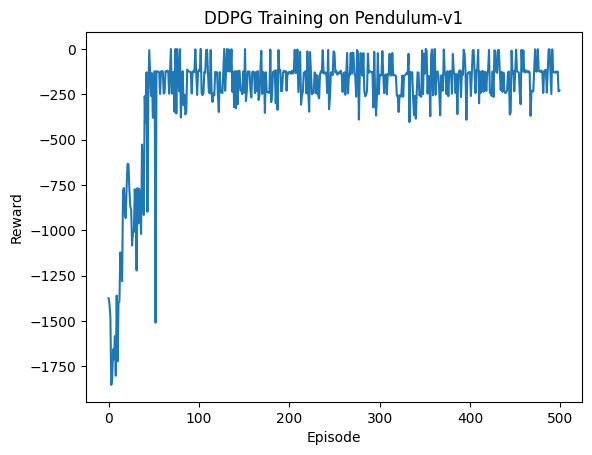

In [12]:
import matplotlib.pyplot as plt

plt.plot(episode_rewards)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('DDPG Training on Pendulum-v1')
plt.show()


## Testing the DDPG Agent

Finally, let's visualize our agent in operation:

In [15]:
env = gym.make(ENV_NAME, render_mode="rgb_array")

images = []
for _ in range(0,5):
  observation, _ = env.reset()
  done = False
  while not done:
      with torch.no_grad():
        action = agent.select_action(observation)

      observation, reward, terminated, truncated, _ = env.step(action)
      done = terminated or truncated
      image = env.render()
      images.append(image)

save_video(images, path='/content/DDPG_pendulum.mp4')

Video saved.
